# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Dhaka Obesity Dataset](https://www.kaggle.com/datasets/abbas829/dhaka-obesity-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Dhaka Obesity.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Gender,Age,Height (m),Weight (kg),Family history of overweight,High caloric food consumption,Vegetable consumption frequency,Daily main meals frequency,Between-meal food consumption frequency,Smoking,Alcohol intake,Daily water intake,Monitor calories,Physical exercise,Daily device usage duration,Mode of transportation,Obesity level
0,Male,29,1.65,101.0,Yes,Yes,Sometimes,Three,Frequently,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Private Car,Obesity_Type_II
1,Female,25,1.65,53.0,No,No,Always,Three,Always,No,I do not drink,Between 1 and 2 L,No,Almost Everyday,More than 5 hours,Public Transportation,Normal_Weight
2,Male,23,1.70,70.0,No,No,Always,Between 1-2,Sometimes,Yes,Sometimes,Less than a liter,No,I do not have,More than 5 hours,Public Transportation,Normal_Weight
3,Male,22,1.68,112.0,Yes,Yes,Sometimes,Three,Frequently,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Public Transportation,Obesity_Type_II
4,Male,19,1.75,67.0,No,Yes,Always,Three,Sometimes,Yes,I do not drink,Between 1 and 2 L,No,2 or 4 days,3-5 hours,Bike,Normal_Weight


## last Five row

In [4]:
df.tail()

,Gender,Age,Height (m),Weight (kg),Family history of overweight,High caloric food consumption,Vegetable consumption frequency,Daily main meals frequency,Between-meal food consumption frequency,Smoking,Alcohol intake,Daily water intake,Monitor calories,Physical exercise,Daily device usage duration,Mode of transportation,Obesity level
2177,Male,18,1.63,41.0,No,No,Sometimes,Three,Sometimes,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Public Transportation,Insufficient_Weight
2178,Male,22,1.60,118.0,Yes,Yes,Never,Three,Frequently,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Private Car,Obesity_Type_III
2179,Male,24,1.75,79.0,Yes,Yes,Always,Between 1-2,No,No,I do not drink,More than 2 L,Yes,Almost Everyday,More than 5 hours,Private Car,Overweight
2180,Male,28,1.68,88.0,Yes,Yes,Sometimes,Between 1-2,Sometimes,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Public Transportation,Obesity_Type_I
2181,Male,15,1.60,49.0,No,Yes,Sometimes,Between 1-2,Sometimes,No,I do not drink,More than 2 L,No,Almost Everyday,More than 5 hours,Rickshaw,Normal_Weight


## Shape of our dataset

In [5]:
df.shape

(2182, 17)

## List out all columns

In [6]:
df.columns

Index(['Gender', 'Age', 'Height (m)', 'Weight (kg)',
       'Family history of overweight', 'High caloric food consumption',
       'Vegetable consumption frequency', 'Daily main meals frequency',
       'Between-meal food consumption frequency', 'Smoking', 'Alcohol intake',
       'Daily water intake', 'Monitor calories', 'Physical exercise',
       'Daily device usage duration', 'Mode of transportation',
       'Obesity level'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Gender                                      object
Age                                          int64
Height (m)                                 float64
Weight (kg)                                float64
Family history of overweight                object
High caloric food consumption               object
Vegetable consumption frequency             object
Daily main meals frequency                  object
Between-meal food consumption frequency     object
Smoking                                     object
Alcohol intake                              object
Daily water intake                          object
Monitor calories                            object
Physical exercise                           object
Daily device usage duration                 object
Mode of transportation                      object
Obesity level                               object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   2182 non-null   object 
 1   Age                                      2182 non-null   int64  
 2   Height (m)                               2182 non-null   float64
 3   Weight (kg)                              2182 non-null   float64
 4   Family history of overweight             2182 non-null   object 
 5   High caloric food consumption            2182 non-null   object 
 6   Vegetable consumption frequency          2182 non-null   object 
 7   Daily main meals frequency               2182 non-null   object 
 8   Between-meal food consumption frequency  2182 non-null   object 
 9   Smoking                                  2182 non-null   object 
 10  Alcohol intake                           2182 no

## Check Null Value

In [9]:
df.isnull().sum()

Gender                                     0
Age                                        0
Height (m)                                 0
Weight (kg)                                0
Family history of overweight               0
High caloric food consumption              0
Vegetable consumption frequency            0
Daily main meals frequency                 0
Between-meal food consumption frequency    0
Smoking                                    0
Alcohol intake                             0
Daily water intake                         0
Monitor calories                           0
Physical exercise                          0
Daily device usage duration                0
Mode of transportation                     0
Obesity level                              0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(25)

## Summary

In [11]:
df.describe()

,Age,Height (m),Weight (kg)
count,2182.000000,2182.000000,2182.000000
mean,26.752062,1.627635,73.814207
std,8.425983,0.101239,20.837370
min,15.000000,1.220000,35.000000
25%,22.000000,1.570000,56.000000
50%,24.000000,1.630000,72.000000
75%,28.000000,1.700000,89.000000
max,75.000000,1.880000,150.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

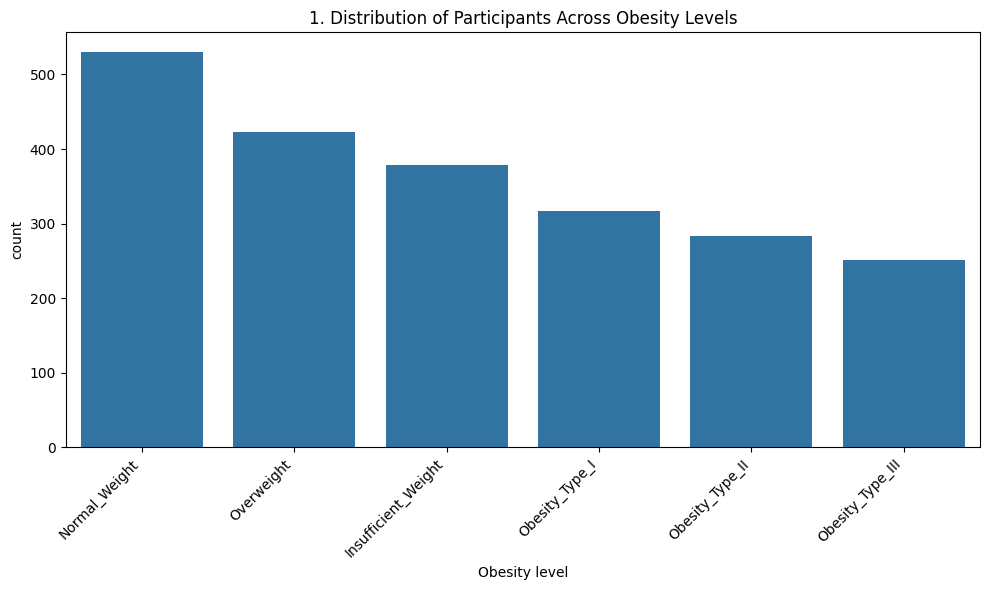

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Obesity level', order=df['Obesity level'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Participants Across Obesity Levels')
plt.xticks(rotation=45, ha='right')
show_fig()
plot_no += 1

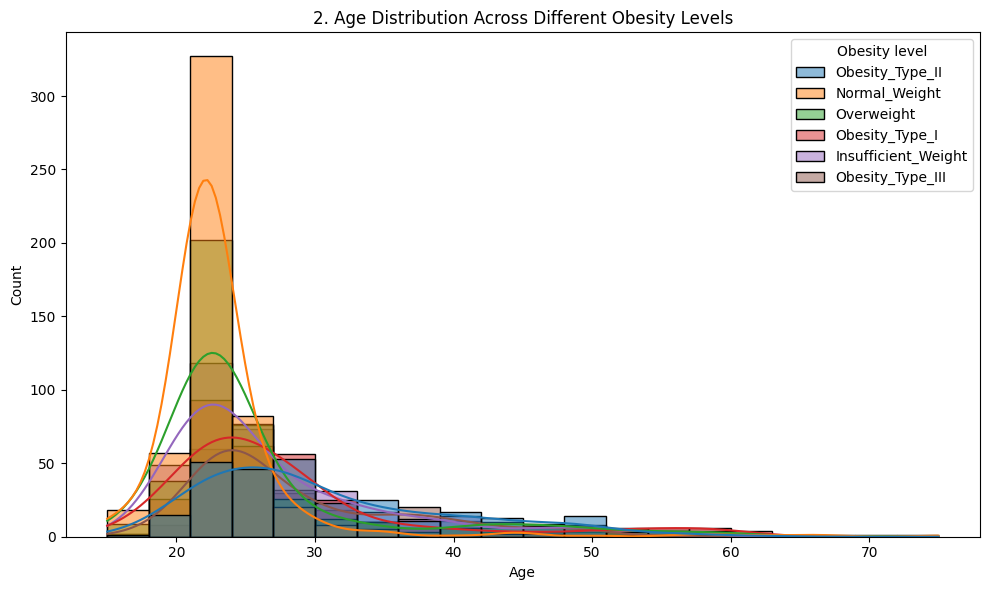

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Obesity level', kde=True, multiple='layer', bins=20)
plt.title(f'{plot_no}. Age Distribution Across Different Obesity Levels')
show_fig()
plot_no += 1

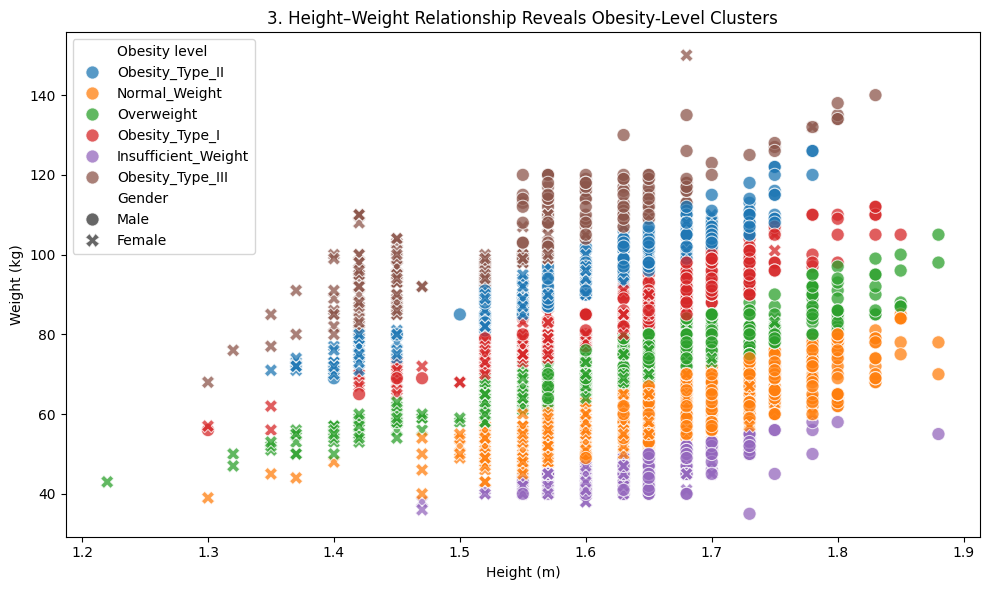

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Height (m)', y='Weight (kg)', hue='Obesity level', style='Gender', s=90, alpha=0.75)
plt.title(f'{plot_no}. Height–Weight Relationship Reveals Obesity-Level Clusters')
show_fig()
plot_no += 1

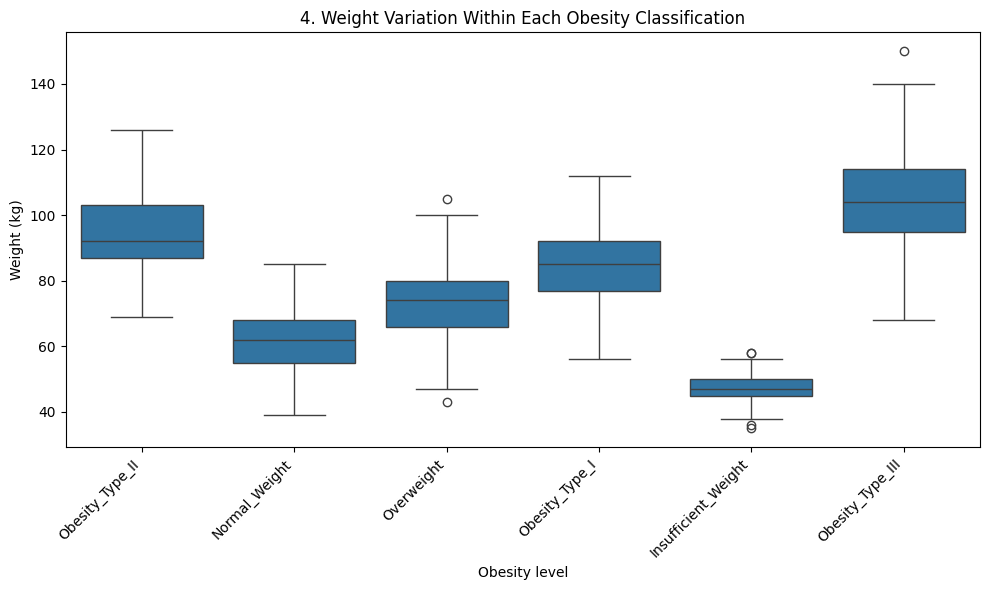

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Obesity level', y='Weight (kg)')
plt.title(f'{plot_no}. Weight Variation Within Each Obesity Classification')
plt.xticks(rotation=45, ha='right')
show_fig()
plot_no += 1

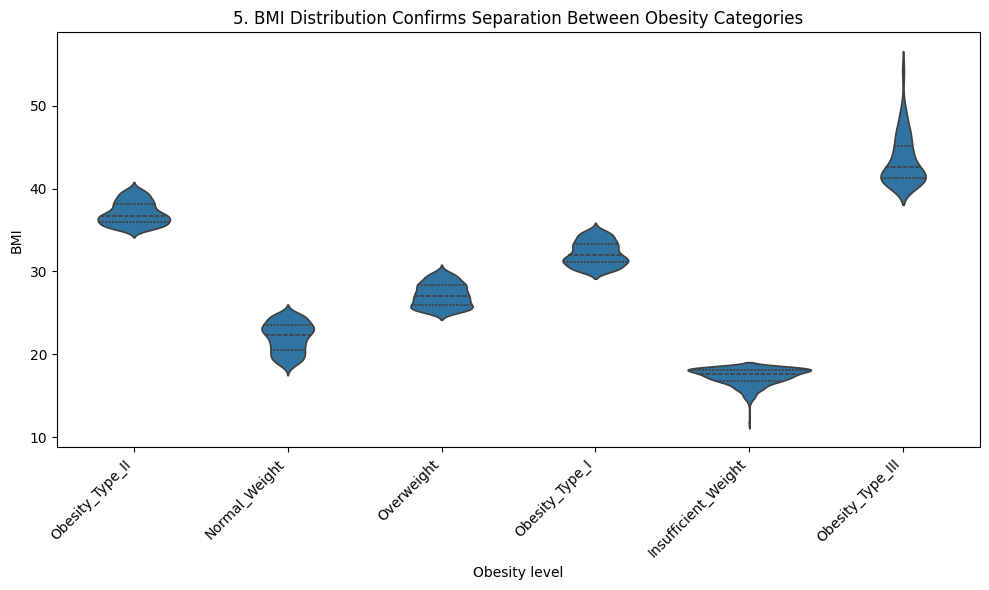

In [17]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df.assign(BMI=df['Weight (kg)'] / df['Height (m)'] ** 2), x='Obesity level', y='BMI', inner='quartile')
plt.title(f'{plot_no}. BMI Distribution Confirms Separation Between Obesity Categories')
plt.xticks(rotation=45, ha='right')
show_fig()
plot_no += 1

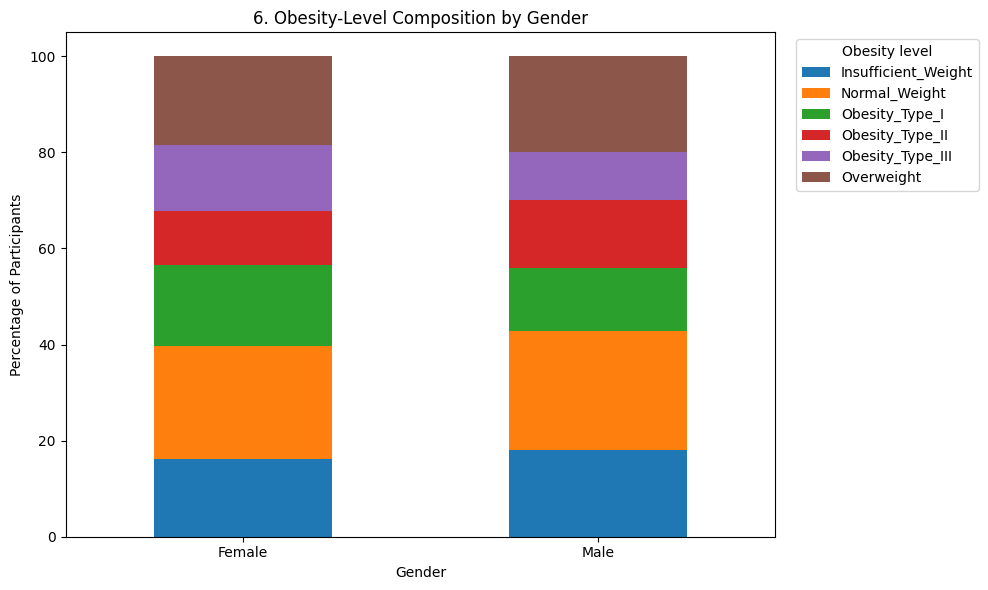

In [18]:
fig = plt.figure(figsize=(10,6))
pd.crosstab(df['Gender'], df['Obesity level'], normalize='index').mul(100).plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Obesity-Level Composition by Gender')
plt.ylabel('Percentage of Participants')
plt.xticks(rotation=0)
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

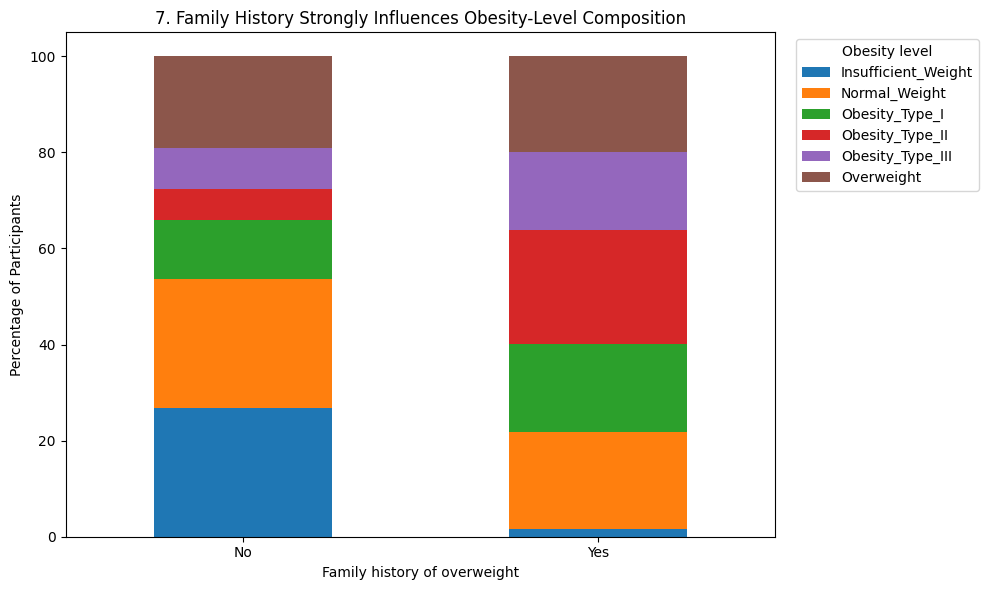

In [19]:
fig = plt.figure(figsize=(10,6))
pd.crosstab(df['Family history of overweight'], df['Obesity level'], normalize='index').mul(100).plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Family History Strongly Influences Obesity-Level Composition')
plt.ylabel('Percentage of Participants')
plt.xticks(rotation=0)
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

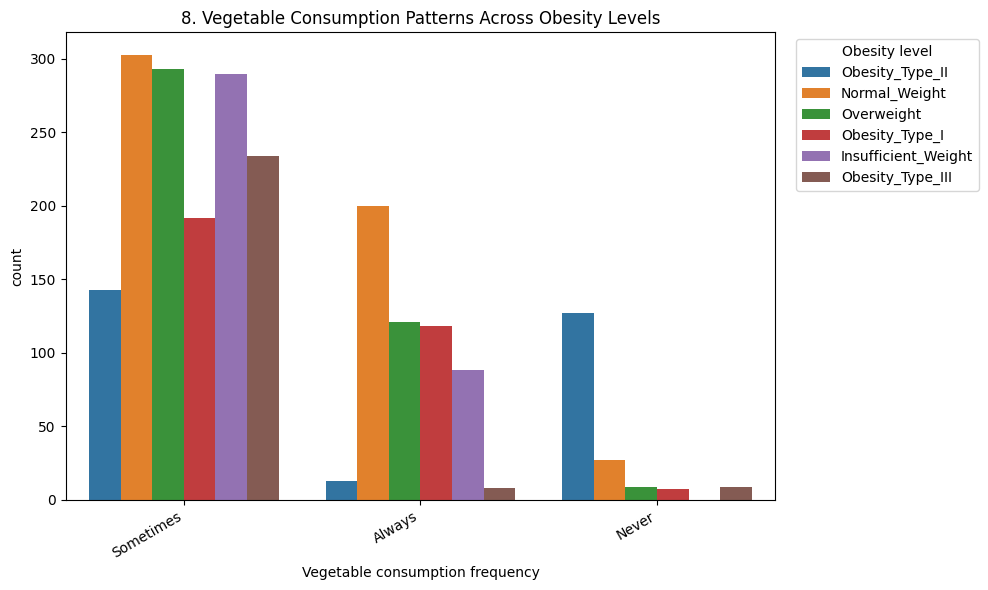

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Vegetable consumption frequency', hue='Obesity level', order=df['Vegetable consumption frequency'].value_counts().index)
plt.title(f'{plot_no}. Vegetable Consumption Patterns Across Obesity Levels')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

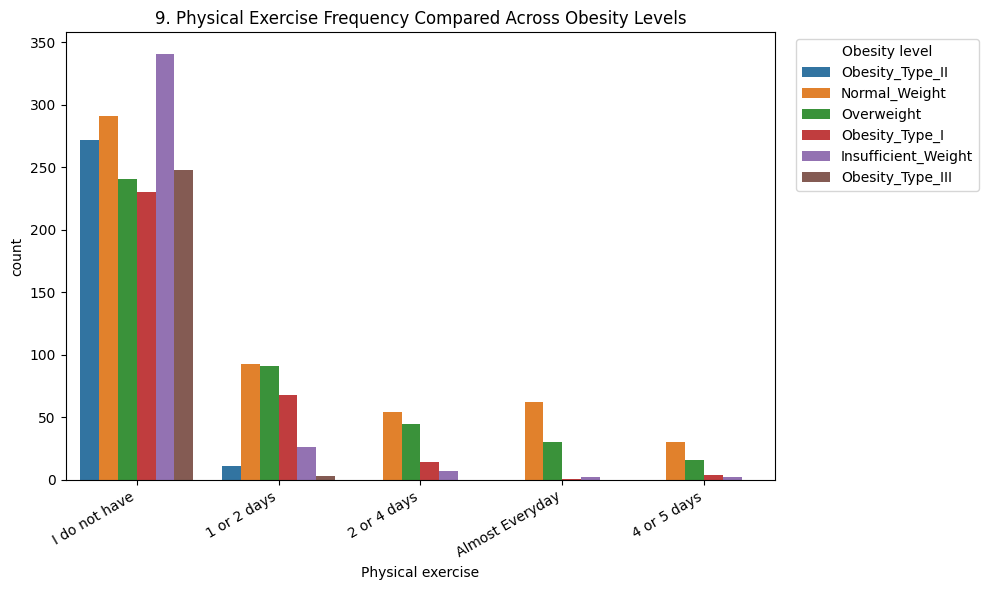

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Physical exercise', hue='Obesity level', order=df['Physical exercise'].value_counts().index)
plt.title(f'{plot_no}. Physical Exercise Frequency Compared Across Obesity Levels')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

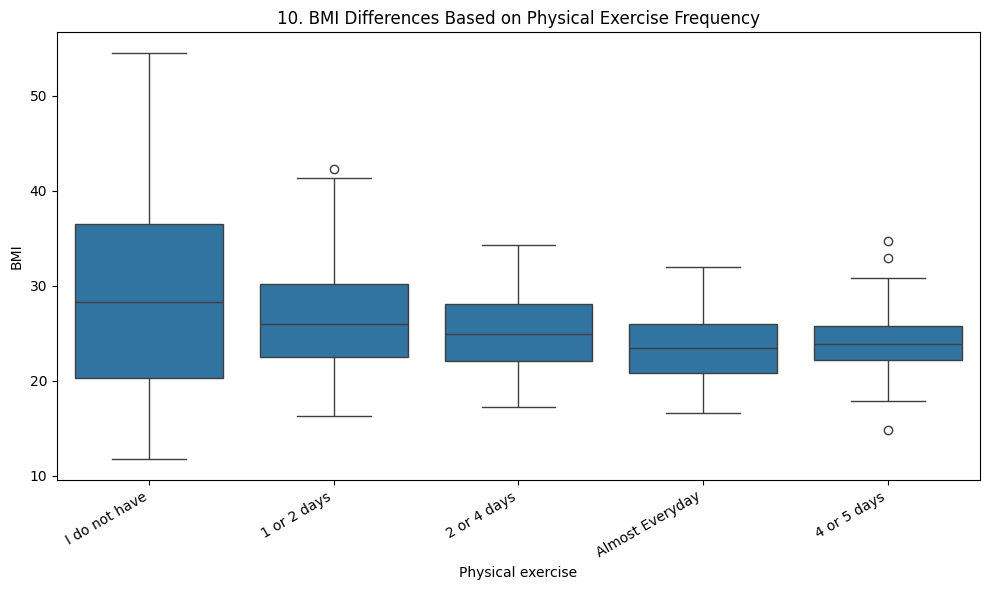

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df.assign(BMI=df['Weight (kg)'] / df['Height (m)'] ** 2), x='Physical exercise', y='BMI', order=df['Physical exercise'].value_counts().index)
plt.title(f'{plot_no}. BMI Differences Based on Physical Exercise Frequency')
plt.xticks(rotation=30, ha='right')
show_fig()
plot_no += 1

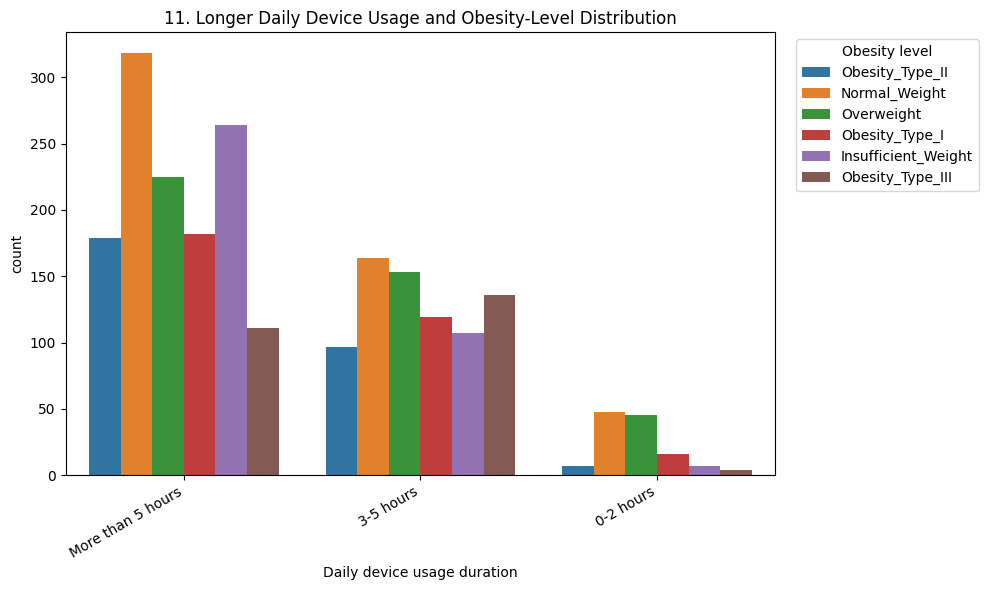

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Daily device usage duration', hue='Obesity level', order=df['Daily device usage duration'].value_counts().index)
plt.title(f'{plot_no}. Longer Daily Device Usage and Obesity-Level Distribution')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

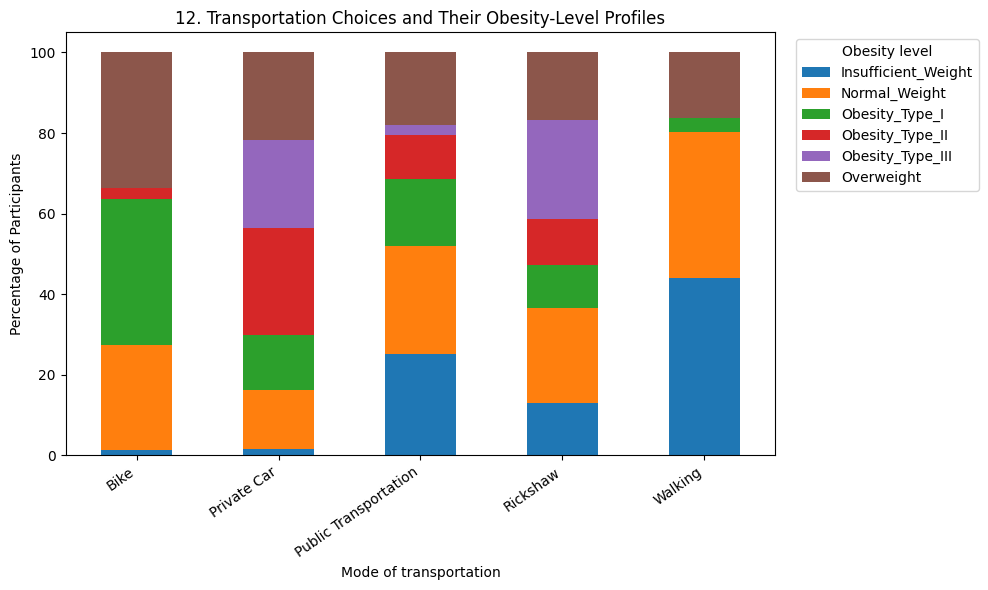

In [24]:
fig = plt.figure(figsize=(10,6))
pd.crosstab(df['Mode of transportation'], df['Obesity level'], normalize='index').mul(100).plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Transportation Choices and Their Obesity-Level Profiles')
plt.ylabel('Percentage of Participants')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

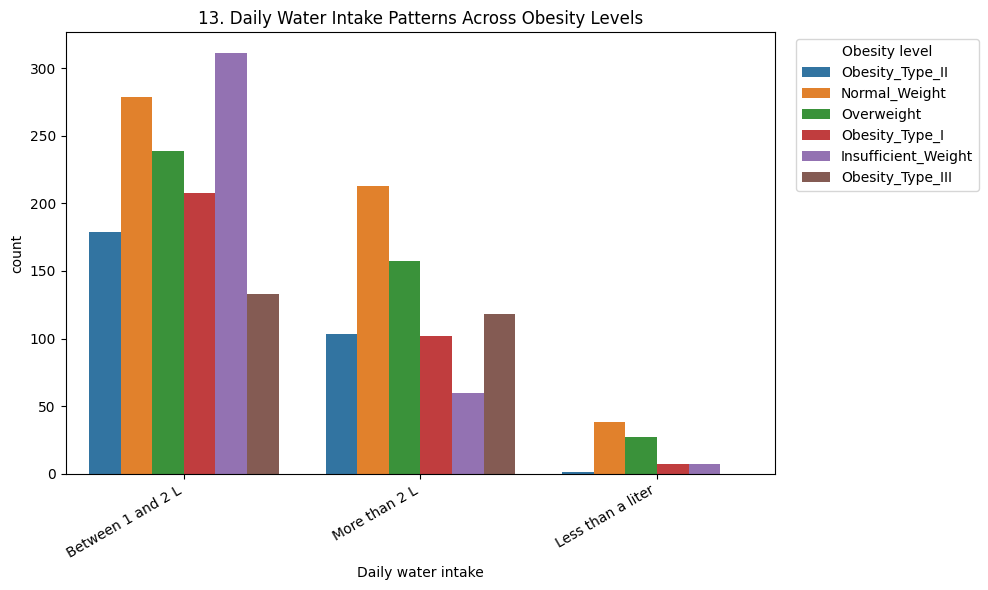

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Daily water intake', hue='Obesity level', order=df['Daily water intake'].value_counts().index)
plt.title(f'{plot_no}. Daily Water Intake Patterns Across Obesity Levels')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

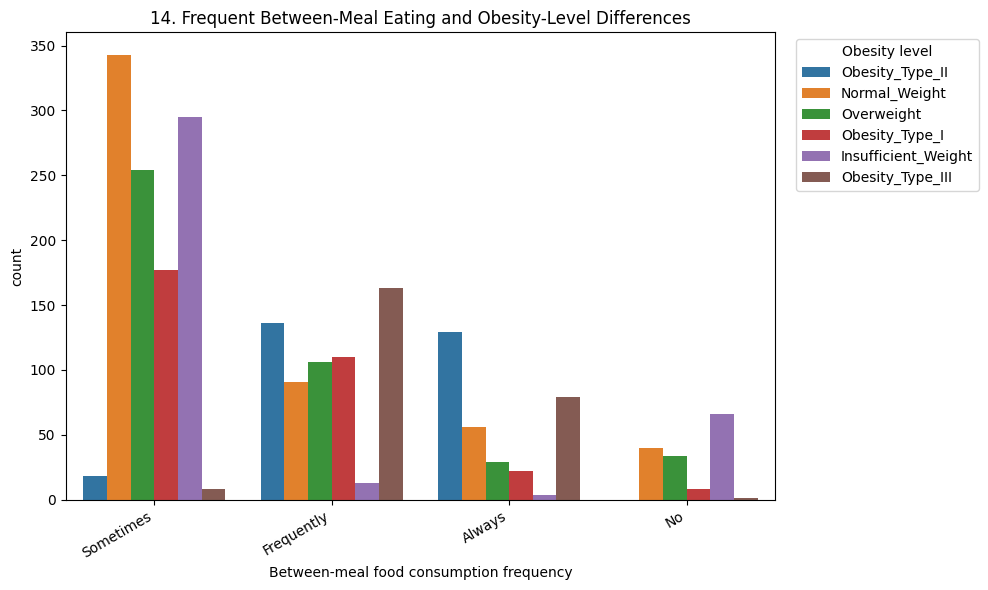

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Between-meal food consumption frequency', hue='Obesity level', order=df['Between-meal food consumption frequency'].value_counts().index)
plt.title(f'{plot_no}. Frequent Between-Meal Eating and Obesity-Level Differences')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

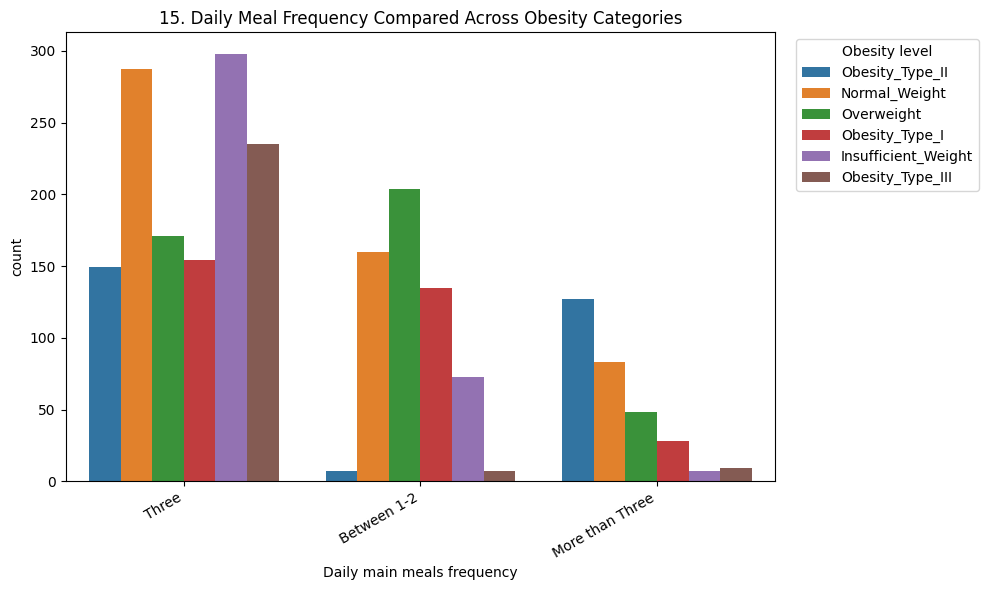

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Daily main meals frequency', hue='Obesity level', order=df['Daily main meals frequency'].value_counts().index)
plt.title(f'{plot_no}. Daily Meal Frequency Compared Across Obesity Categories')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

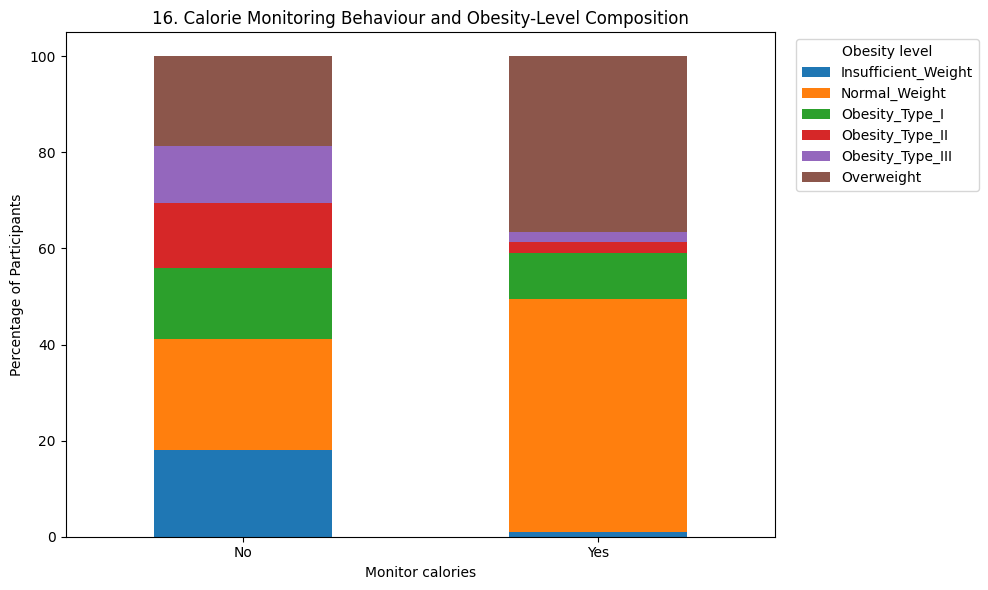

In [28]:
fig = plt.figure(figsize=(10,6))
pd.crosstab(df['Monitor calories'], df['Obesity level'], normalize='index').mul(100).plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Calorie Monitoring Behaviour and Obesity-Level Composition')
plt.ylabel('Percentage of Participants')
plt.xticks(rotation=0)
plt.legend(title='Obesity level', bbox_to_anchor=(1.02, 1), loc='upper left')
show_fig()
plot_no += 1

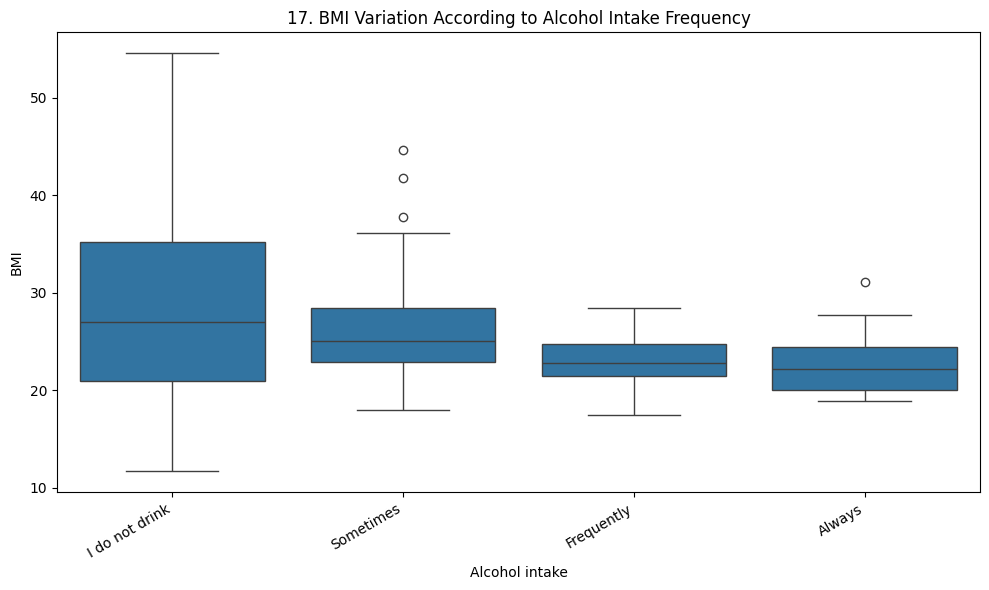

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df.assign(BMI=df['Weight (kg)'] / df['Height (m)'] ** 2), x='Alcohol intake', y='BMI', order=df['Alcohol intake'].value_counts().index)
plt.title(f'{plot_no}. BMI Variation According to Alcohol Intake Frequency')
plt.xticks(rotation=30, ha='right')
show_fig()
plot_no += 1

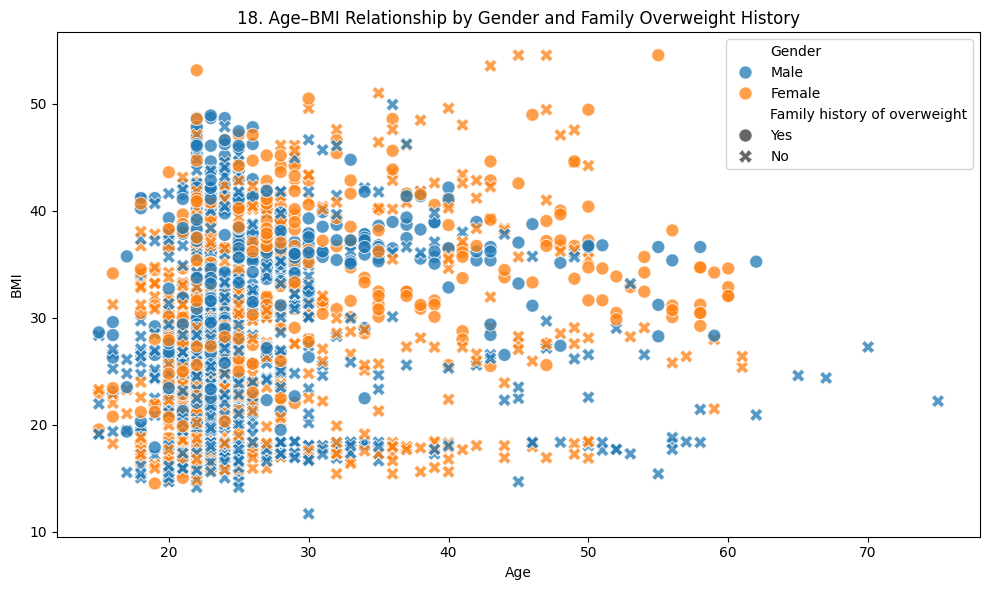

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df.assign(BMI=df['Weight (kg)'] / df['Height (m)'] ** 2), x='Age', y='BMI', hue='Gender', style='Family history of overweight', s=90, alpha=0.75)
plt.title(f'{plot_no}. Age–BMI Relationship by Gender and Family Overweight History')
show_fig()
plot_no += 1

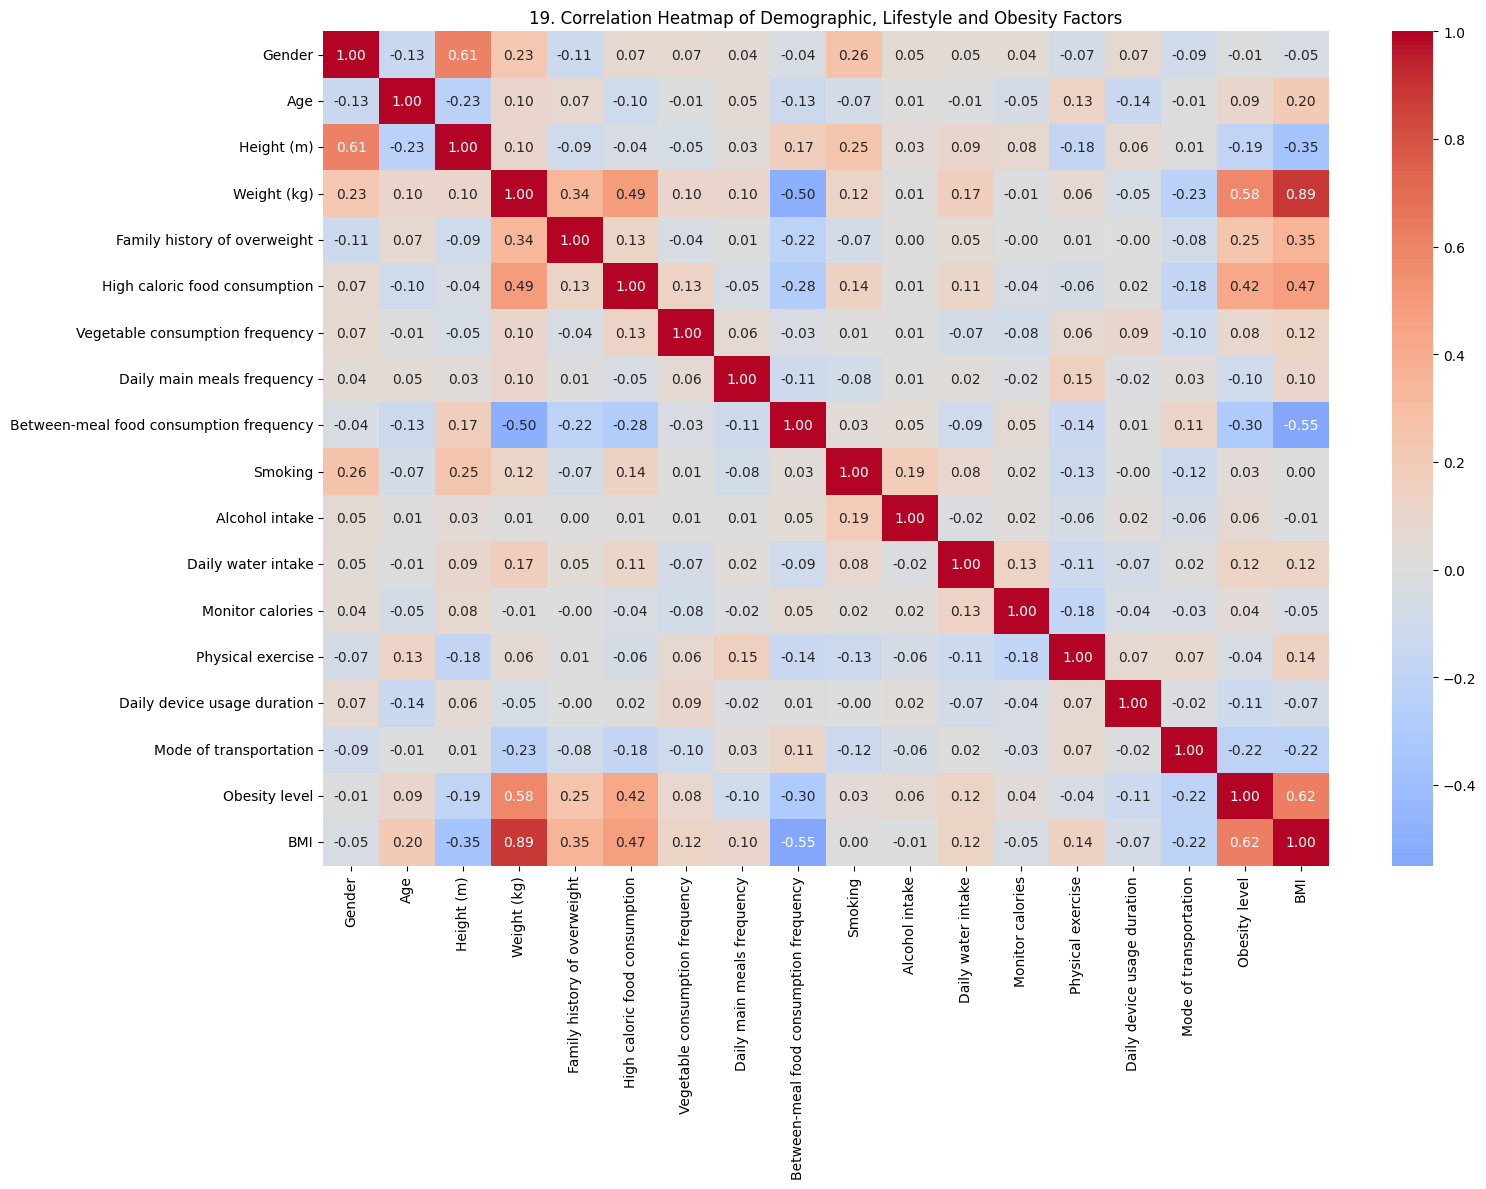

In [31]:
corr_data = df.copy()
corr_data['BMI'] = corr_data['Weight (kg)'] / corr_data['Height (m)'] ** 2
for column in corr_data.select_dtypes(include='object').columns:
    corr_data[column] = corr_data[column].astype('category').cat.codes
corr = corr_data.corr(numeric_only=True)

fig = plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Demographic, Lifestyle and Obesity Factors')
show_fig()
plot_no += 1

# Model Training

## Separate input features and target

In [32]:
X = df.drop(columns=['Obesity level'])
y = df['Obesity level']

## Identify numerical and categorical columns

In [33]:
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object', 'category']).columns

## Create numerical preprocessing pipeline

In [34]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Create categorical preprocessing pipeline

In [35]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine numerical and categorical preprocessing

In [36]:
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_columns),
    ('categorical', categorical_pipeline, categorical_columns)
])

## Create Support Vector Machine pipeline

In [37]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', class_weight='balanced'))
])

## Split data into training and testing sets

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Define model parameter combinations

In [39]:
parameters = {
    'model__C': [1, 5, 10, 20],
    'model__gamma': ['scale', 'auto', 0.01, 0.1]
}

## Find the best model parameters

In [40]:
grid_search = GridSearchCV(
    pipeline,
    parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

## Train the model

In [41]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__C': [1, 5, ...], 'model__gamma': ['scale', 'auto', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


## Select the best trained model

In [42]:
best_model = grid_search.best_estimator_

## Predict obesity levels

In [43]:
y_pred = best_model.predict(X_test)

## Calculate model accuracy

In [44]:
accuracy = accuracy_score(y_test, y_pred)

## Print best model parameters

In [45]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'model__C': 20, 'model__gamma': 0.01}


## Print model accuracy

In [46]:
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 92.45%


## Print classification report

In [47]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.95      0.95        76
      Normal_Weight       0.92      0.91      0.91       106
     Obesity_Type_I       0.92      0.92      0.92        63
    Obesity_Type_II       0.91      0.93      0.92        57
   Obesity_Type_III       0.94      0.96      0.95        50
         Overweight       0.90      0.91      0.90        85

           accuracy                           0.92       437
          macro avg       0.93      0.93      0.93       437
       weighted avg       0.92      0.92      0.92       437



## Get obesity-level class names

In [48]:
class_names = best_model.named_steps['model'].classes_

## Create confusion matrix

In [49]:
cm = confusion_matrix(y_test, y_pred, labels=class_names)

## Plot confusion matrix

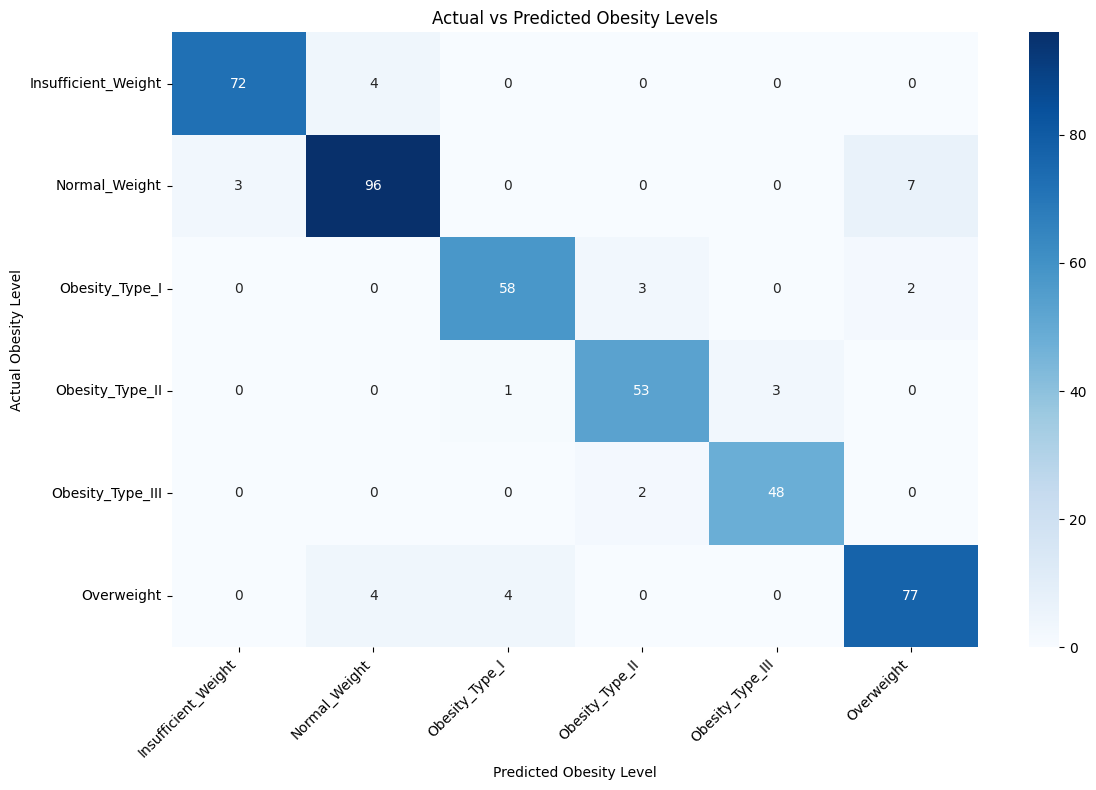

In [50]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Actual vs Predicted Obesity Levels')
plt.xlabel('Predicted Obesity Level')
plt.ylabel('Actual Obesity Level')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()